# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean, cdist
#from dtw import warp
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
from sklearn.preprocessing import MinMaxScaler

numpy.ndarray size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject


In [3]:
P8_df = pd.read_csv('/home/baptiste/Desktop/Emploi/Formation/WildCodeSchool/Side_project/Data/P8.csv', 
                 sep = ';', na_values = 'n.a.')
P10_df = pd.read_csv('/home/baptiste/Desktop/Emploi/Formation/WildCodeSchool/Side_project/Data/P10.csv', 
                  sep = ';', na_values = 'n.a.')

In [4]:
P8_df = P8_df.fillna(method = 'ffill')
P10_df = P10_df.fillna(method = 'ffill')

## Scaling 

On met chaque variable entre 0 et 1 afin d'améliorer les analyses

In [5]:
scaler = MinMaxScaler()

P8_df = pd.DataFrame(scaler.fit_transform(P8_df),
                     index = P8_df.index,
                     columns = P8_df.columns)

P10_df = pd.DataFrame(scaler.fit_transform(P10_df),
                      index = P10_df.index,
                      columns = P10_df.columns)

# Bivariate DTW

In [6]:
def transformer(tple):
    '''
    INPUTS
    ------
        - tple : list
            List of tuples of the transformation vector to apply.
            
    OUTPUT
    ------
        - transform_list : list
            Vector of the X2 positions to apply to X1 data.
    '''
    import operator
    from itertools import groupby
    
    transform_list = []
    for k, g in groupby(tple, operator.itemgetter(0)):
        x = list(g)
        bst_val = []
        for i in x:
            val = i[1]
            pval = P10[val]
            bst_val.append(pval)
        
        pos = np.argmin(abs(np.array(bst_val) - np.mean(bst_val)))
        bst_pos = x[pos][1]
        transform_list.append(bst_pos)

    return transform_list

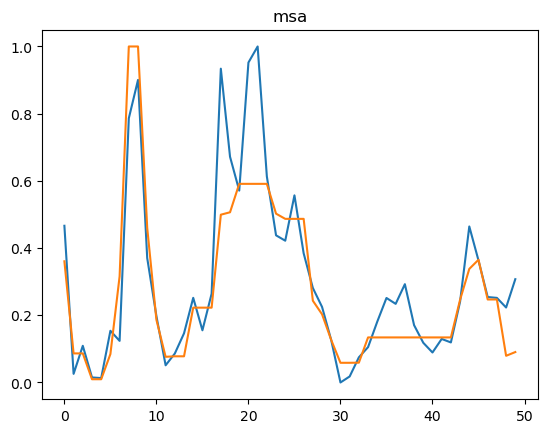

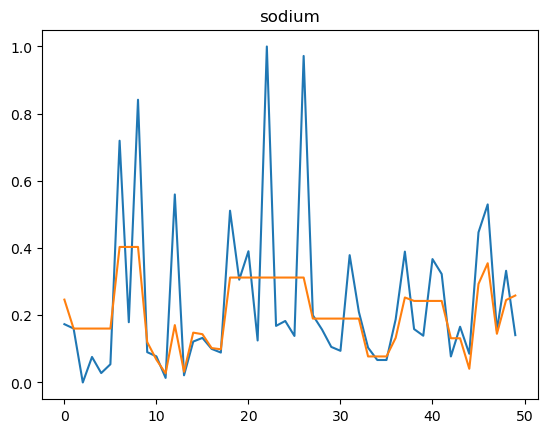

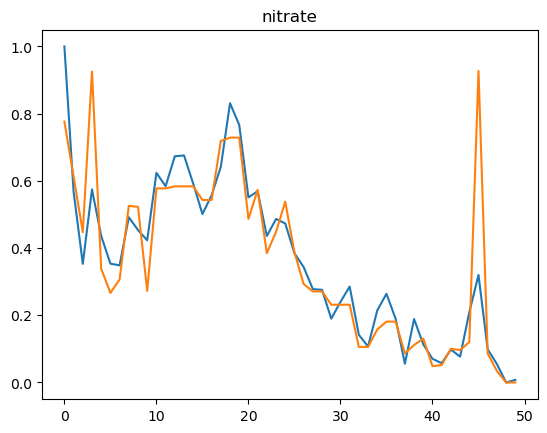

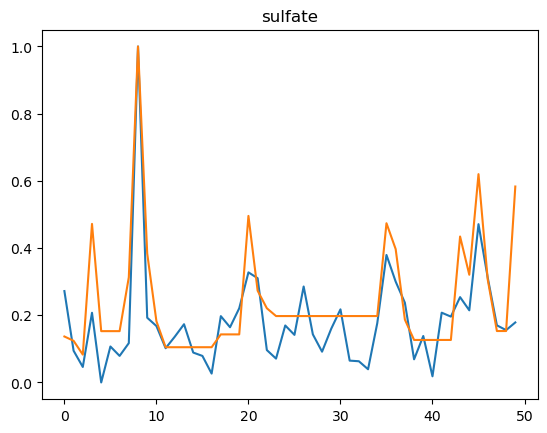

In [7]:
cols = ['msa', 'sodium', 'nitrate', 'sulfate']

for i in cols :
    P8 = np.array(P8_df[i],  dtype = np.double)
    P10 = np.array(P10_df[i], dtype = np.double)
    
    tuple_transform = dtw.warping_path(P8, P10)
    list_transform = transformer(tuple_transform)

    plt.plot(P8)
    plt.plot(list_transform)
    plt.title(i)
    plt.show()

# Multivariate DTW

Le DTW est appliqué entre 2 carottes et séparément pour chaque variable. Le résultat est moyenné pour obtenir le vecteur de transformation à appliquer pour la paire de carottes.

In [15]:
cols = ['msa', 'nitrate']

paths_df = pd.DataFrame(columns = ['x', 'y'])

for i in cols :    
    P8 = np.array(P8_df[i],  dtype = np.double)
    P10 = np.array(P10_df[i], dtype = np.double)
    
    distance, paths = dtw.warping_paths(P8, P10)
    best_path = pd.DataFrame(dtw.best_path(paths), columns = ['x', 'y'])
    paths_df = pd.concat([paths_df, best_path])

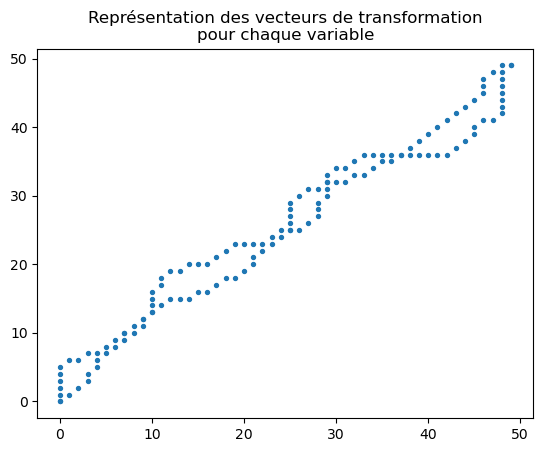

In [16]:
plt.scatter(paths_df.x, paths_df.y, s = 8)
plt.title('Représentation des vecteurs de transformation\npour chaque variable')
plt.show()

In [17]:
df_dtw = round(paths_df.groupby(['x']).mean())
df_dtw = df_dtw.astype('int64')
df_dtw['tuple'] = list(df_dtw.itertuples(index = True, name = None))

In [18]:
tuple_transform = list(zip(df_dtw.index, df_dtw.y))

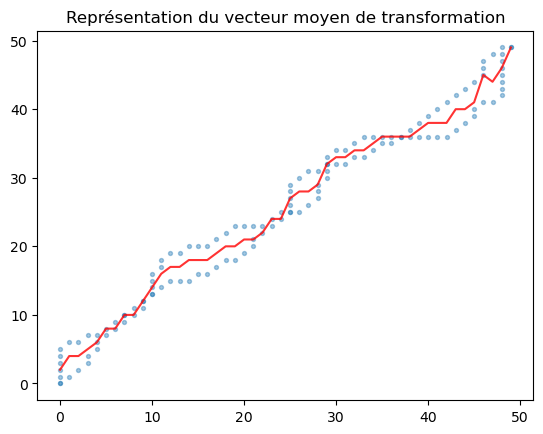

In [19]:
plt.scatter(paths_df.x, paths_df.y, s = 8, alpha = 0.4)
plt.plot(df_dtw['y'], color = 'red', alpha = 0.8)
plt.title('Représentation du vecteur moyen de transformation')
plt.show()

## Représentation du résultat sur chaque variable

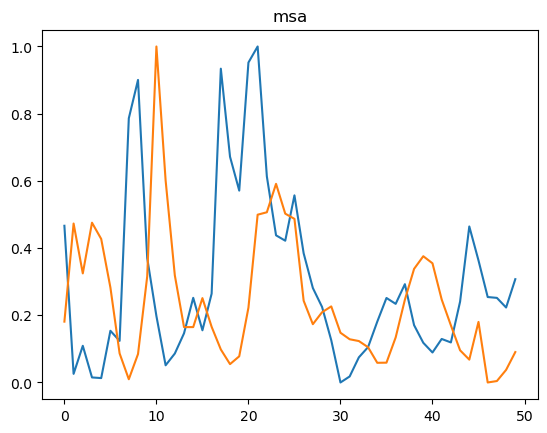

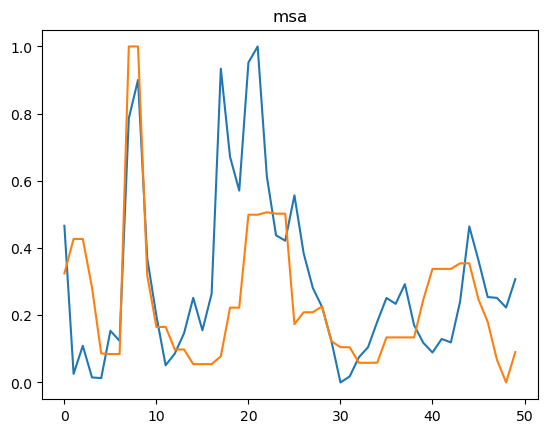

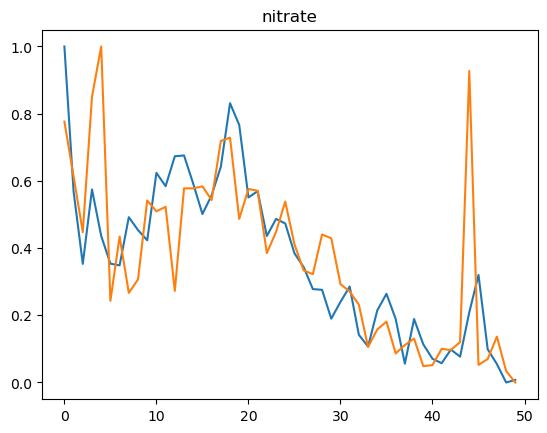

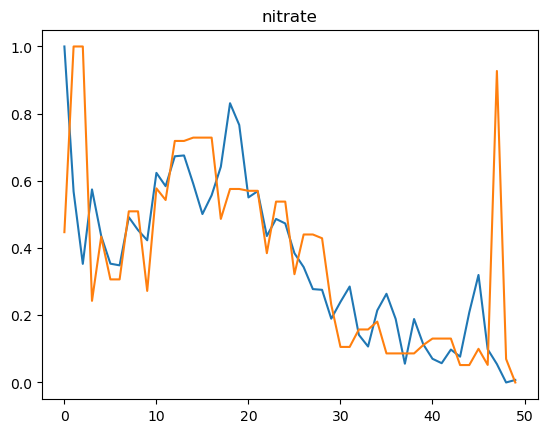

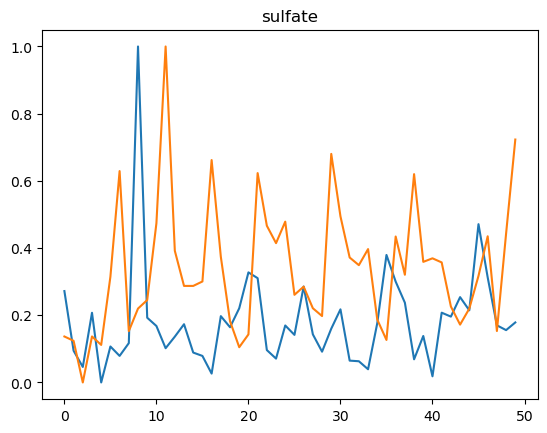

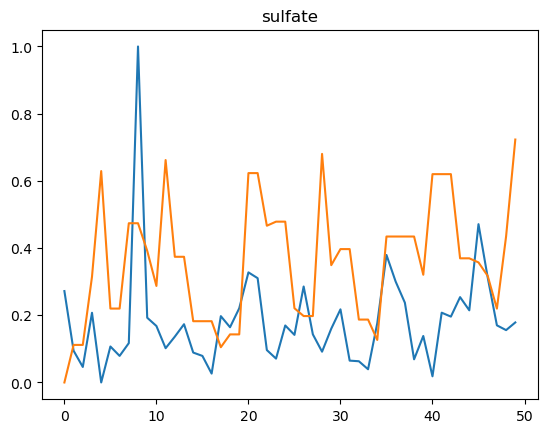

In [20]:
cols = ['msa', 'nitrate', 'sulfate']
for i in cols :
    new_P10 = []
    
    for j in tuple_transform :
        new_P10.append(P10_df.loc[j[1], i])

    plt.plot(P8_df[i])
    plt.plot(P10_df[i])
    plt.title(i)
    plt.show()        

    plt.plot(P8_df[i])
    plt.plot(new_P10)
    plt.title(i)
    plt.show()

In [41]:
#cols = ['msa', 'sodium', 'nitrate', 'sulfate']
#for i in cols :
#    dtwvis.plot_warping(P8df[i], P10df[i], df_dtw['tuple'])

In [69]:
distance, paths = dtw.warping_paths(P8, P10)
best_path = dtw.best_path(paths)
path = dtw.warping_path(P8, P10)

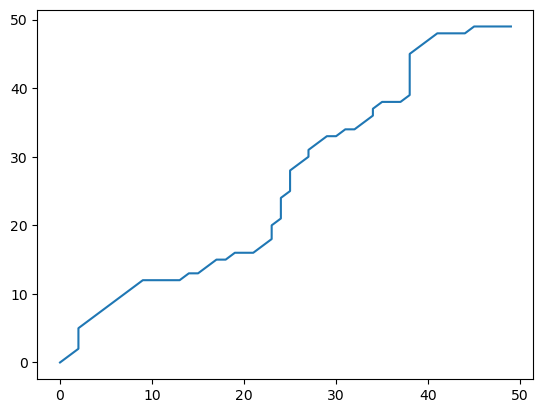

In [168]:
plt.plot([x[0] for x in best_path], [x[1] for x in best_path])
plt.show()

## DTW Bivarié

In [24]:
def dp(dist_mat):
    """
    Find minimum-cost path through matrix `dist_mat` using dynamic programming.

    The cost of a path is defined as the sum of the matrix entries on that
    path. See the following for details of the algorithm:

    - http://en.wikipedia.org/wiki/Dynamic_time_warping
    - https://www.ee.columbia.edu/~dpwe/resources/matlab/dtw/dp.m

    The notation in the first reference was followed, while Dan Ellis's code
    (second reference) was used to check for correctness. Returns a list of
    path indices and the cost matrix.
    """

    N, M = dist_mat.shape
    
    # Initialize the cost matrix
    cost_mat = np.zeros((N + 1, M + 1))
    for i in range(1, N + 1):
        cost_mat[i, 0] = np.inf
    for i in range(1, M + 1):
        cost_mat[0, i] = np.inf

    # Fill the cost matrix while keeping traceback information
    traceback_mat = np.zeros((N, M))
    for i in range(N):
        for j in range(M):
            penalty = [
                cost_mat[i, j],      # match (0)
                cost_mat[i, j + 1],  # insertion (1)
                cost_mat[i + 1, j]]  # deletion (2)
            i_penalty = np.argmin(penalty)
            cost_mat[i + 1, j + 1] = dist_mat[i, j] + penalty[i_penalty]
            traceback_mat[i, j] = i_penalty

    # Traceback from bottom right
    i = N - 1
    j = M - 1
    path = [(i, j)]
    while i > 0 or j > 0:
        tb_type = traceback_mat[i, j]
        if tb_type == 0:
            # Match
            i = i - 1
            j = j - 1
        elif tb_type == 1:
            # Insertion
            i = i - 1
        elif tb_type == 2:
            # Deletion
            j = j - 1
        path.append((i, j))

    # Strip infinity edges from cost_mat before returning
    cost_mat = cost_mat[1:, 1:]
    return (path[::-1], cost_mat)

In [28]:
x = np.array(P8_df['msa'])
y = np.array(P10_df['msa'])

# Distance matrix
N = x.shape[0]
M = y.shape[0]
dist_mat = np.zeros((N, M))
for i in range(N):
    for j in range(M):
        dist_mat[i, j] = abs(x[i] - y[j])

In [29]:
print(dp(dist_mat)[1])

[[ 0.28529643  0.29196307  0.43376301 ... 12.20841955 12.63735381
  13.01321886]
 [ 0.44073419  0.73269725  0.59089731 ...  8.85537236  8.8671723
   8.93204144]
 [ 0.51267539  0.80463845  0.806335   ...  7.16234981  7.23404644
   7.25267385]
 ...
 [ 9.54235294  9.49145918  8.21877127 ...  5.45737376  5.60023426
   5.69002557]
 [ 9.58439417  9.74138101  8.32022652 ...  5.5001923   5.64305281
   5.73284412]
 [ 9.71075335  9.74999806  8.33736384 ...  5.6223616   5.7701893
   5.8599806 ]]


Alignment cost: 5.8600
Normalized alignment cost: 0.0586


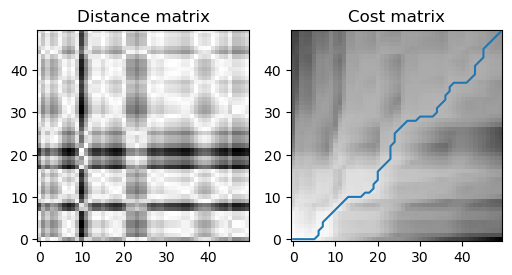

In [30]:
# DTW
path, cost_mat = dp(dist_mat)
print("Alignment cost: {:.4f}".format(cost_mat[N - 1, M - 1]))
print("Normalized alignment cost: {:.4f}".format(cost_mat[N - 1, M - 1]/(N + M)))

plt.figure(figsize=(6, 4))
plt.subplot(121)
plt.title("Distance matrix")
plt.imshow(dist_mat, cmap=plt.cm.binary, interpolation="nearest", origin="lower")
plt.subplot(122)
plt.title("Cost matrix")
plt.imshow(cost_mat, cmap=plt.cm.binary, interpolation="nearest", origin="lower")
x_path, y_path = zip(*path)
plt.plot(y_path, x_path);

In [31]:
path1 = np.array([], dtype = int)
for i in path :
    path1 = np.append(path1, i[0])
    
print(path1)

[ 0  0  0  0  0  0  1  2  3  4  5  6  7  8  9 10 10 10 10 11 11 12 13 14
 15 16 17 18 19 20 21 22 23 24 25 26 27 28 28 28 29 29 29 29 30 31 32 33
 34 35 36 37 37 37 37 38 39 40 41 42 43 44 45 46 47 48 49]


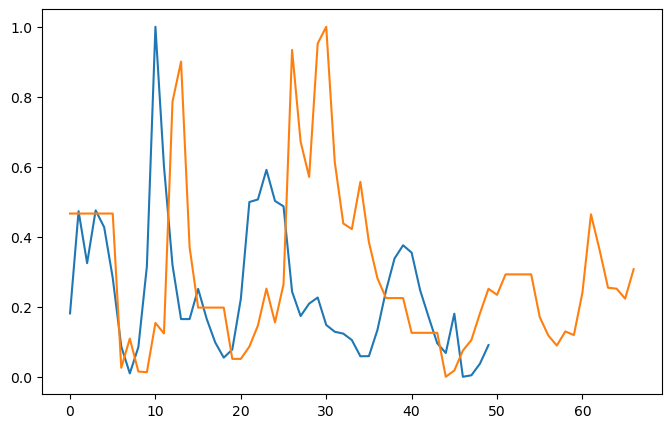

In [32]:
plt.figure(figsize = (8, 5))
plt.plot(y)
plt.plot(x[path1])
plt.show()

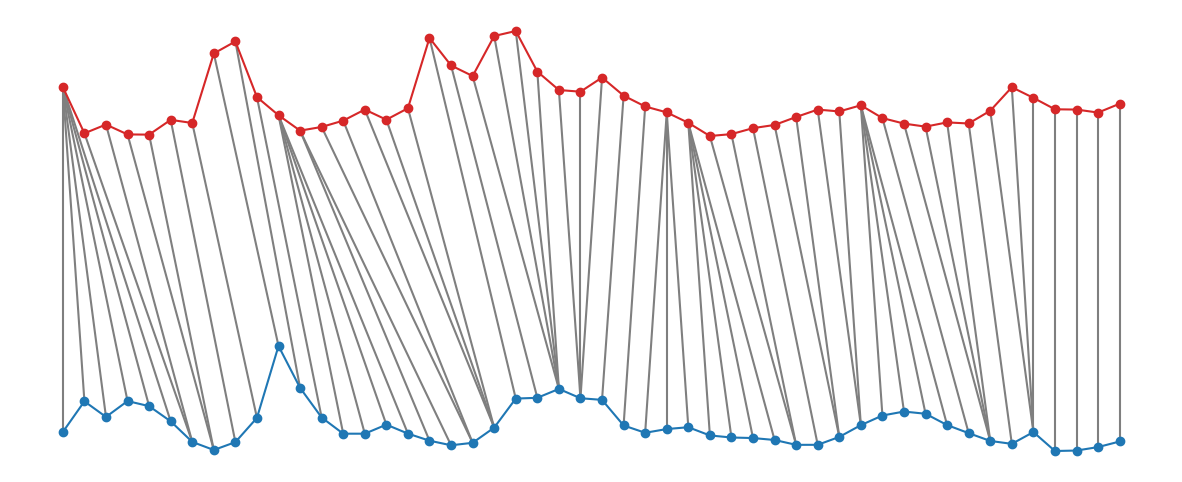

In [33]:
plt.figure(figsize = (15, 6))
for x_i, y_j in path:
    plt.plot([x_i, y_j], [x[x_i] + 1.5, y[y_j] - 1.5], c="C7")
plt.plot(np.arange(x.shape[0]), x + 1.5, "-o", c="C3")
plt.plot(np.arange(y.shape[0]), y - 1.5, "-o", c="C0")
plt.axis("off")
plt.show()

Text(0.5, 1.0, 'msa')

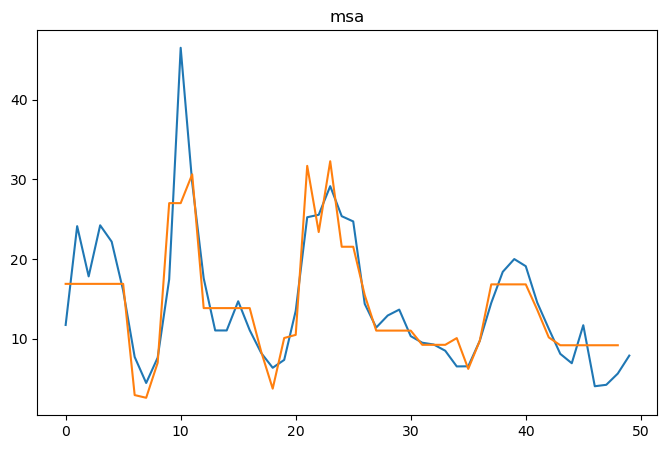

In [10]:
query = np.array(P8_df['msa'])
ref = np.array(P10_df['msa'])
a = dtw(ref, query)
wt = warp(a,index_reference=True)

plt.figure(figsize = (8, 5))
plt.plot(ref)
plt.plot(query[wt])
plt.gca().set_title('msa')

## Multivarié

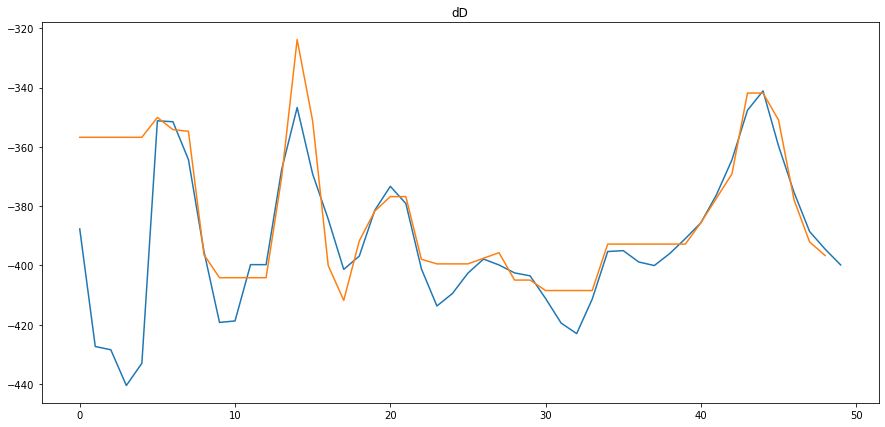

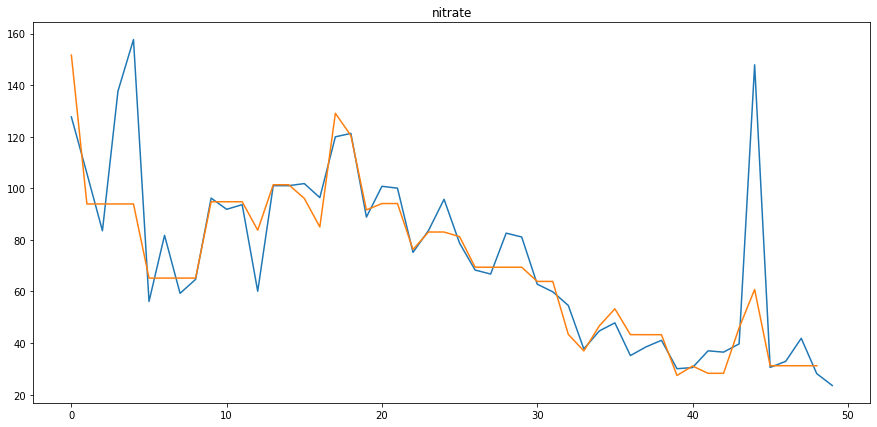

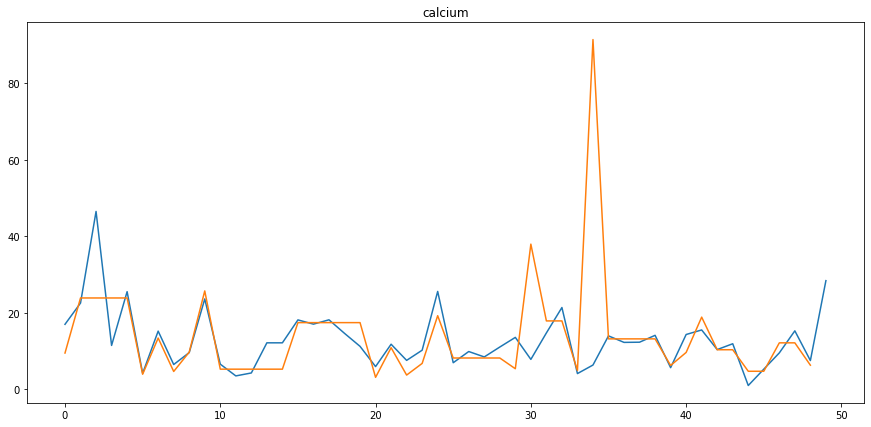

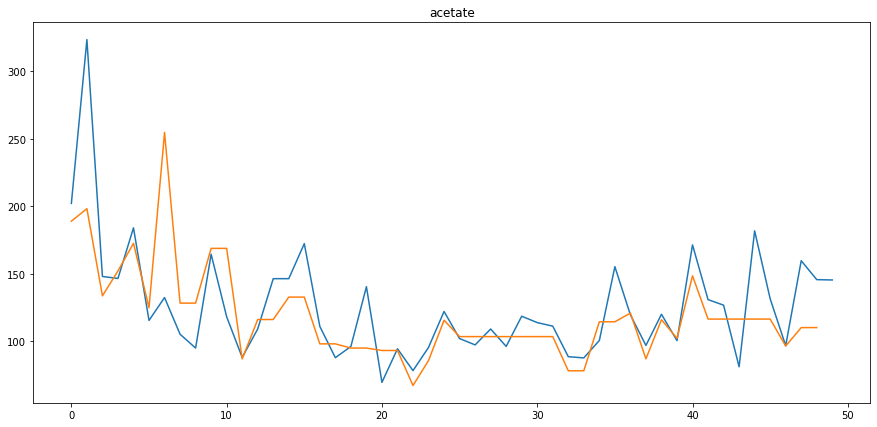

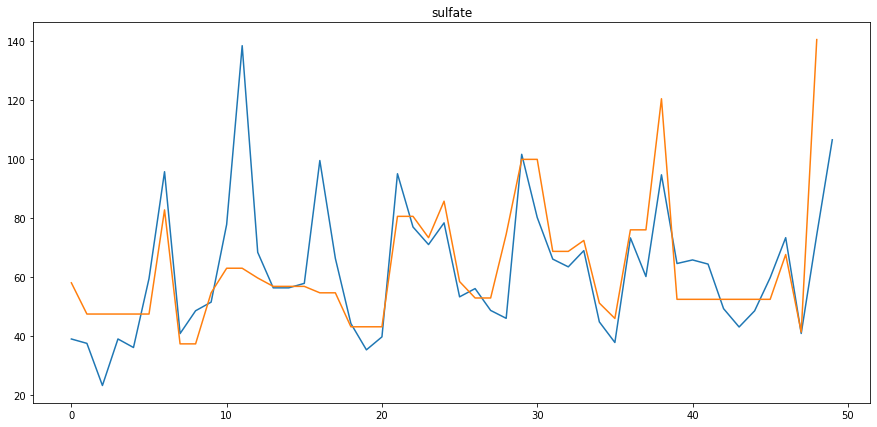

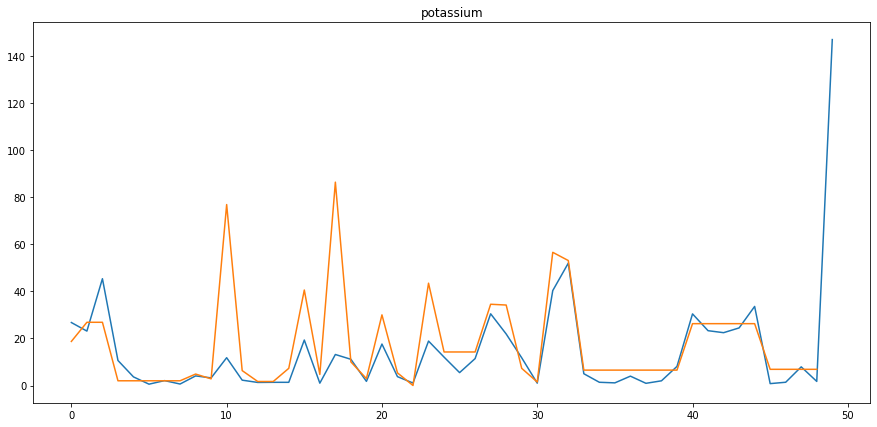

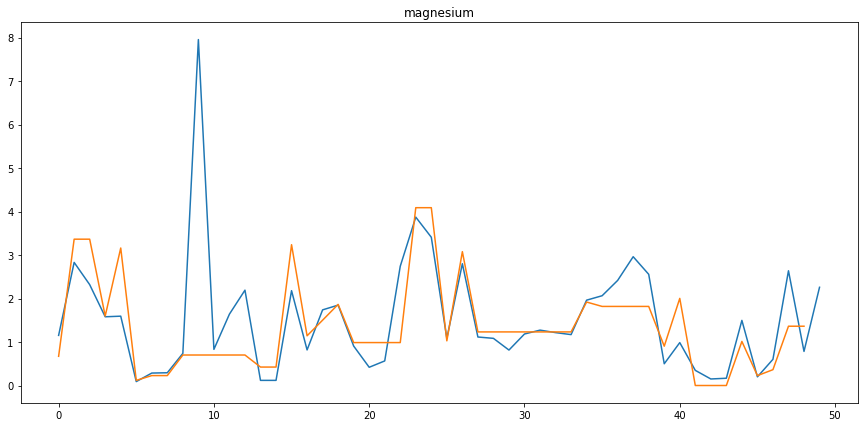

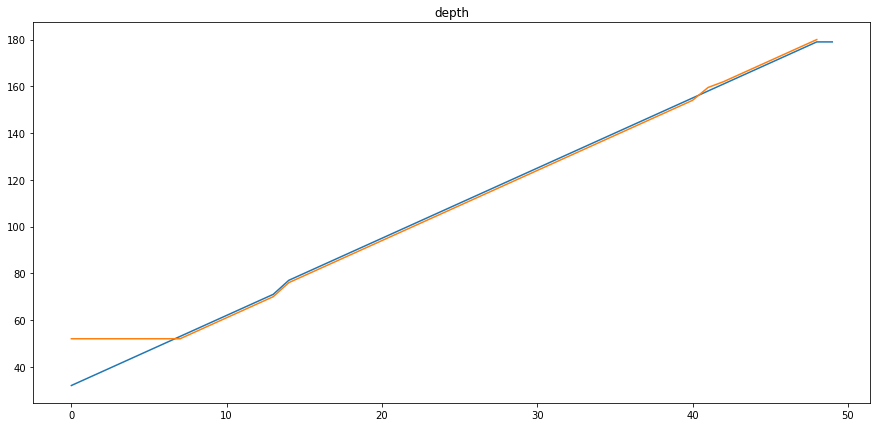

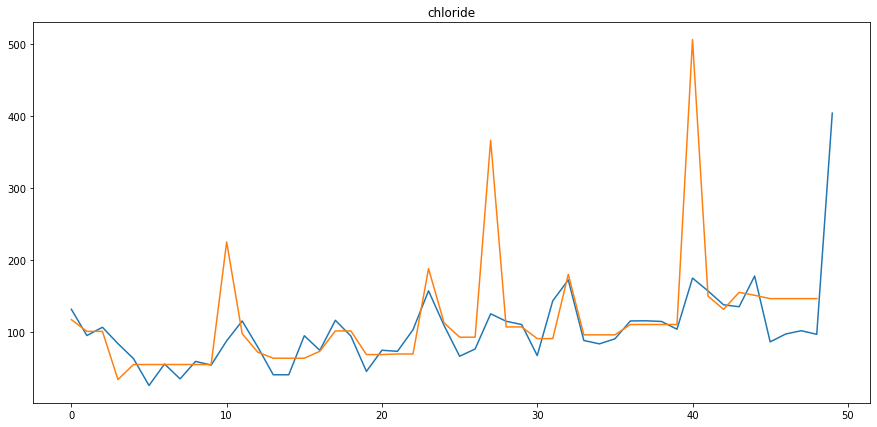

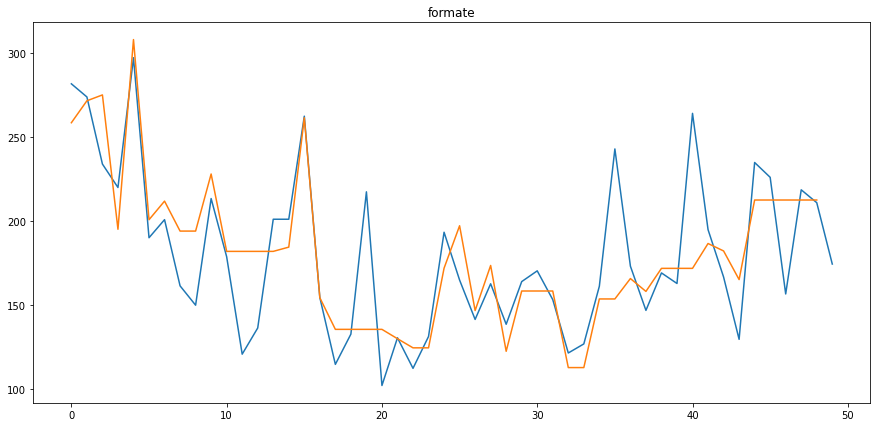

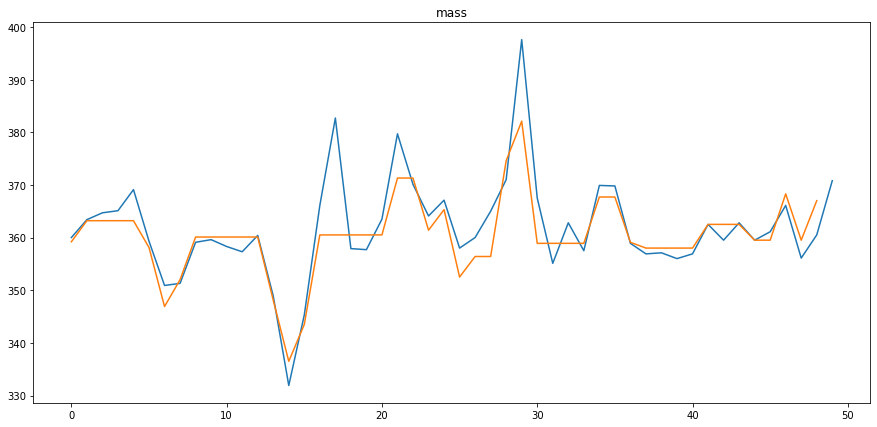

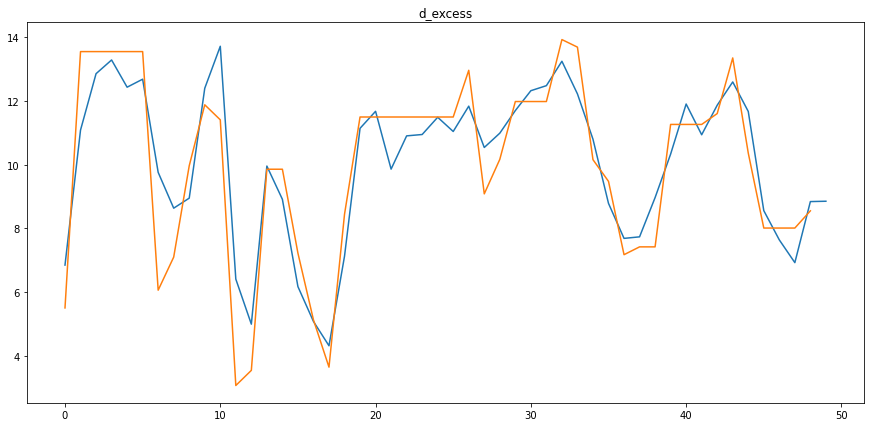

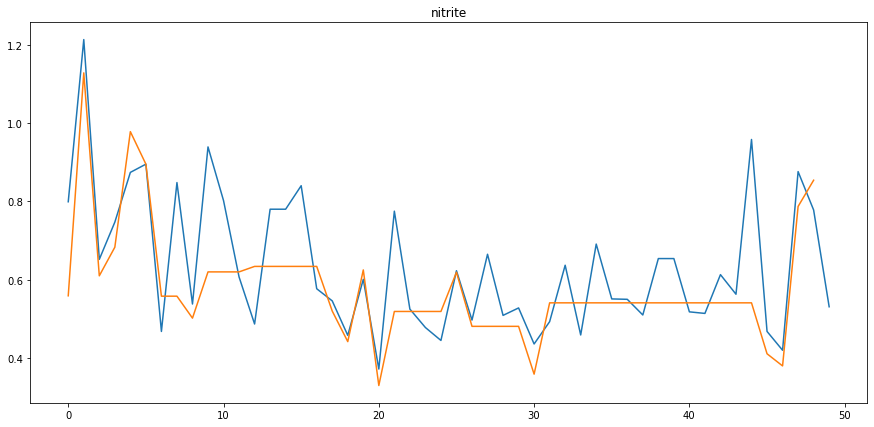

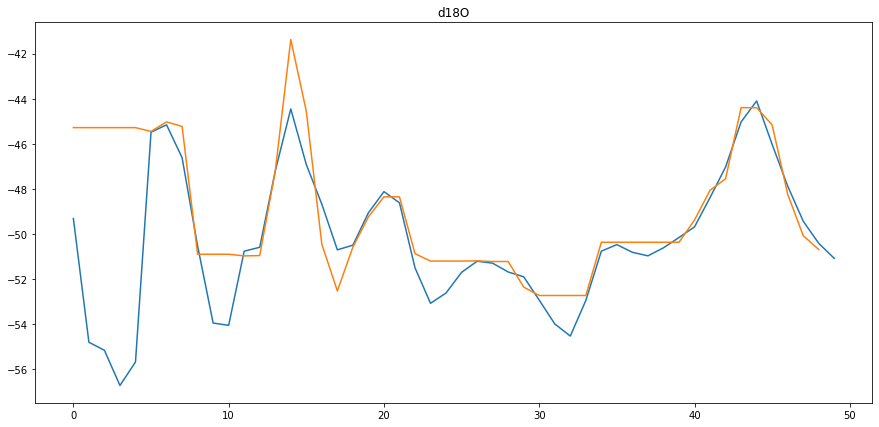

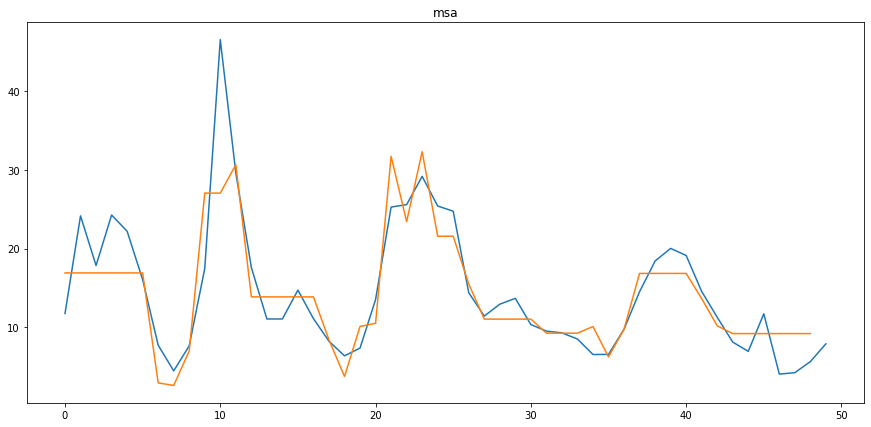

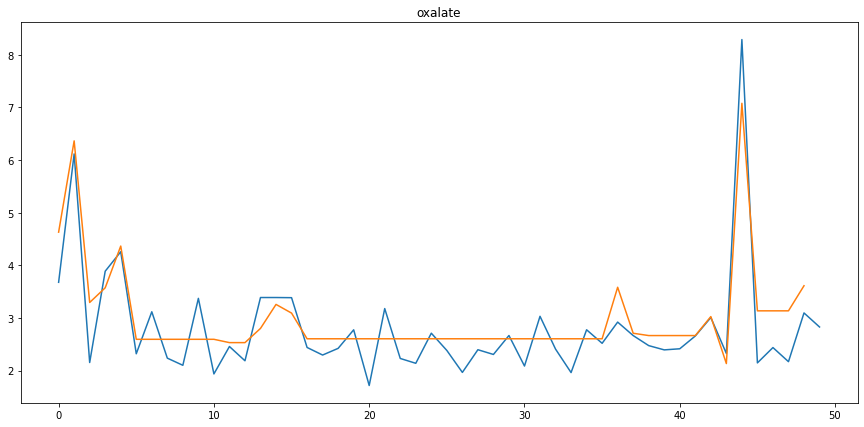

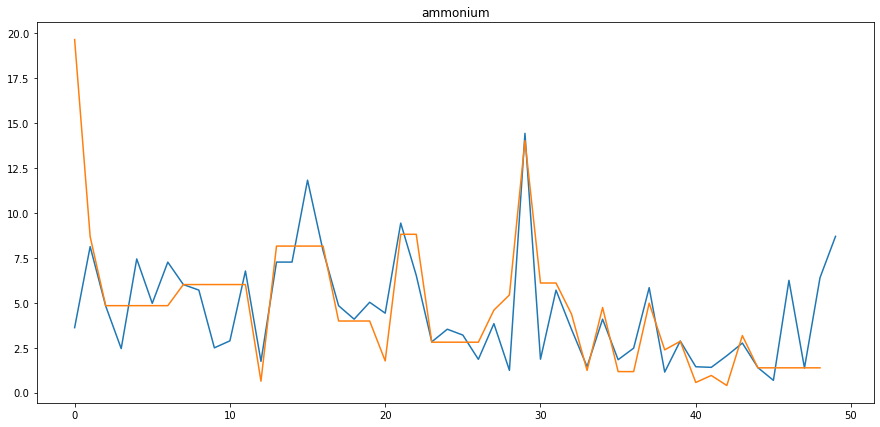

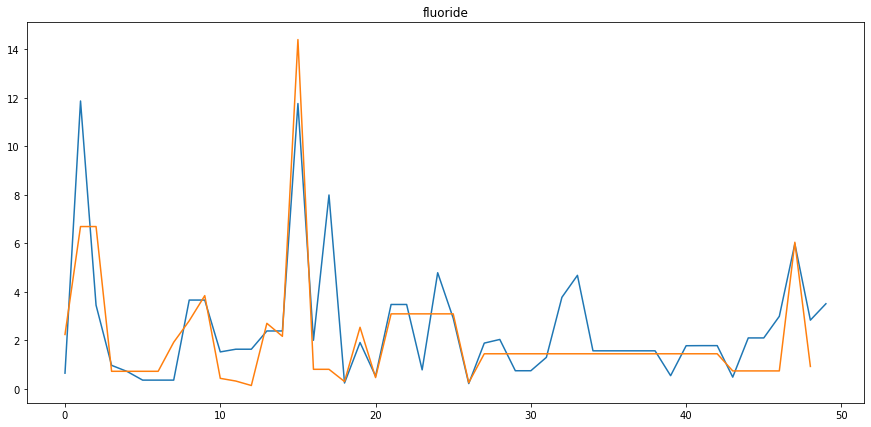

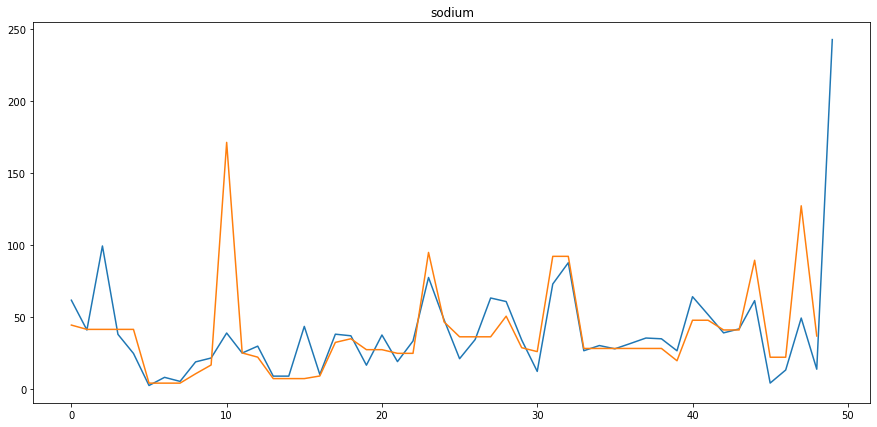

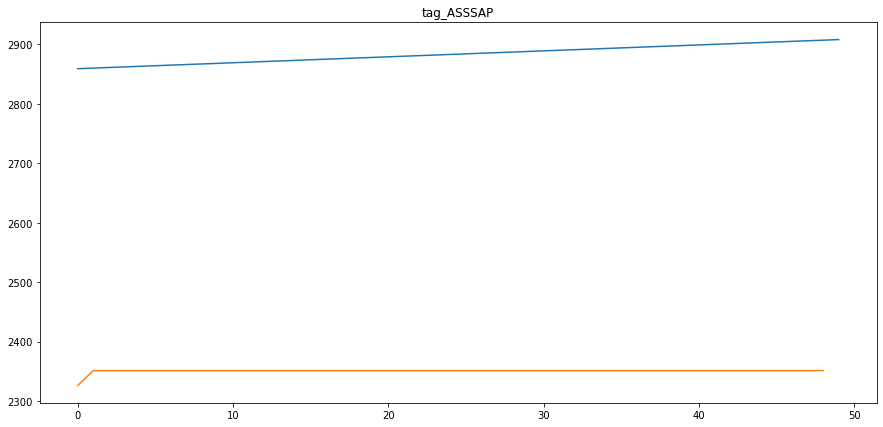

In [63]:
cols = list(set(P8.columns) & set(P10.columns))
for c in cols :
    query = np.array(P8[c])
    ref = np.array(P10[c])
    a = dtw(ref, query, keep_internals = True)
    wt = warp(a,index_reference=True)

    plt.figure(figsize = (15, 7))
    plt.plot(ref)
    plt.plot(query[wt])
    plt.gca().set_title(c)